# 01. Baseline: классический декодер RS-кодов

В этом ноутбуке:
1. Описание кода RS(255, 223)
2. Модель канала (QSC + erasures)
3. Сравнение Classic vs Classic+hint
4. Мотивация для нейросетевого подхода

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from reedsolo import RSCodec, ReedSolomonError
import random

np.random.seed(42)

## 1. Код Рида-Соломона RS(255, 223)

Параметры:
- n = 255 — длина кодового слова
- k = 223 — длина сообщения  
- t = 16 — корректирующая способность (число исправляемых ошибок)
- Поле: GF(2^8)

In [3]:
N = 255
K = 223
NSYM = 32
T = 16

rsc = RSCodec(NSYM)

print(f'Код: RS({N}, {K})')
print(f'Символов чётности: {NSYM}')
print(f'Корректирующая способность: t = {T} ошибок')

Код: RS(255, 223)
Символов чётности: 32
Корректирующая способность: t = 16 ошибок


In [4]:
message = os.urandom(K)
codeword = rsc.encode(message)

print(f'Сообщение: {len(message)} байт')
print(f'Кодовое слово: {len(codeword)} байт')

Сообщение: 223 байт
Кодовое слово: 255 байт


## 2. Модель канала

Комбинация двух каналов:

**QSC (q-ary Symmetric Channel):**
- Каждый символ с вероятностью p_err заменяется на случайный

**Канал со стираниями:**
- Каждый символ с вероятностью p_erase заменяется на 0

In [5]:
def qsc_channel(codeword: bytes, p: float) -> bytes:
    noisy = bytearray(codeword)
    for i in range(len(noisy)):
        if random.random() < p:
            noisy[i] = random.randint(0, 255)
    return bytes(noisy)

def qsc_erasure_channel(codeword, p_err, p_erase):
    noisy = bytearray(codeword)
    erasures = []

    for i in range(len(noisy)):
        r = random.random()
        if r < p_erase:
            noisy[i] = 0
            erasures.append(i)
        elif r < p_erase + p_err:
            noisy[i] = random.randint(0, 255)

    return bytes(noisy), erasures


In [6]:
P_ERR = 0.02
P_ERASE = 0.06

noisy, erase_pos = qsc_erasure_channel(codeword, P_ERR, P_ERASE)

changes = sum(1 for a, b in zip(codeword, noisy) if a != b)

print(f'Параметры канала: p_err={P_ERR}, p_erase={P_ERASE}')
print(f'Ожидаемое число ошибок (QSC): {N * P_ERR:.1f}')
print(f'Ожидаемое число стираний: {N * P_ERASE:.1f}')
print(f'Реальное число изменений: {changes}')
print(f'Известных стираний: {len(erase_pos)}')

Параметры канала: p_err=0.02, p_erase=0.06
Ожидаемое число ошибок (QSC): 5.1
Ожидаемое число стираний: 15.3
Реальное число изменений: 17
Известных стираний: 14


## 3. Граница декодирования

Декодер RS может исправить комбинацию ошибок (e) и стираний (s) если:

$$2e + s \leq 2t$$

где:
- e — число ошибок (неизвестна позиция)
- s — число стираний (известна позиция)
- t = 16 — корректирующая способность

**Вывод:** стирание "стоит" вдвое дешевле ошибки!

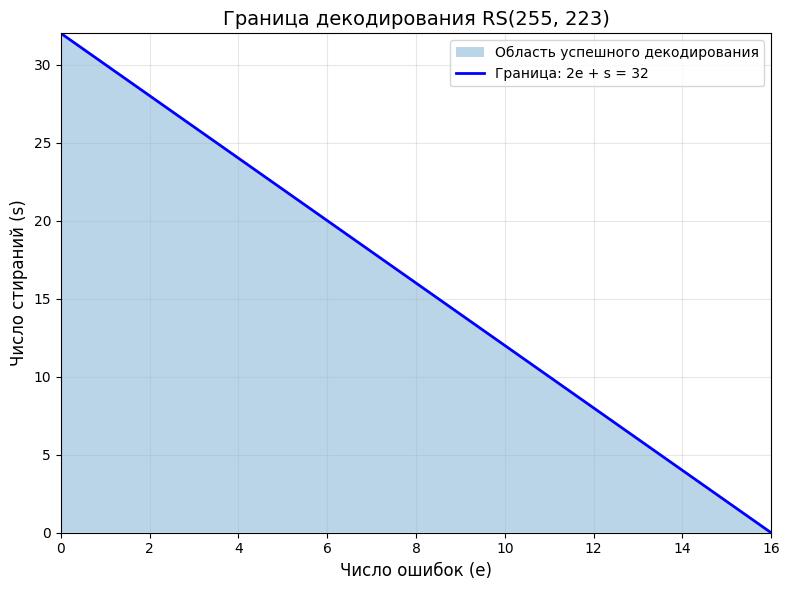

In [7]:
e_vals = np.arange(0, T + 1)
s_max = 2 * T - 2 * e_vals

plt.figure(figsize=(8, 6))
plt.fill_between(e_vals, s_max, alpha=0.3, label='Область успешного декодирования')
plt.plot(e_vals, s_max, 'b-', linewidth=2, label='Граница: 2e + s = 32')
plt.xlabel('Число ошибок (e)', fontsize=12)
plt.ylabel('Число стираний (s)', fontsize=12)
plt.title('Граница декодирования RS(255, 223)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, T)
plt.ylim(0, 2 * T)
plt.tight_layout()
plt.show()

## 4. Сравнение декодеров

Сравним два сценария:

1. **Classic** — декодер не знает позиции стираний, все повреждения = ошибки
2. **Classic + hint** — декодер знает позиции стираний (идеальный оракул)

In [8]:
def evaluate_classic(p_err, p_erase, num_samples=1000):
    success = 0
    
    for _ in range(num_samples):
        msg = os.urandom(K)
        codeword = rsc.encode(msg)
        noisy, _ = qsc_erasure_channel(codeword, p_err, p_erase)
        
        try:
            decoded, _, _ = rsc.decode(noisy)
            if bytes(decoded) == msg:
                success += 1
        except ReedSolomonError:
            pass
    
    return success / num_samples


def evaluate_classic_hint(p_err, p_erase, num_samples=1000):
    success = 0
    
    for _ in range(num_samples):
        msg = os.urandom(K)
        codeword = rsc.encode(msg)
        noisy, erase_pos = qsc_erasure_channel(codeword, p_err, p_erase)
        
        try:
            decoded, _, _ = rsc.decode(noisy, erase_pos=erase_pos)
            if bytes(decoded) == msg:
                success += 1
        except ReedSolomonError:
            pass
    
    return success / num_samples

In [9]:
P_ERR = 0.02
P_ERASE = 0.06
NUM_SAMPLES = 1000

print(f'Параметры: p_err={P_ERR}, p_erase={P_ERASE}')
print(f'Число тестов: {NUM_SAMPLES}')
print()

fsr_classic = evaluate_classic(P_ERR, P_ERASE, NUM_SAMPLES)
fsr_hint = evaluate_classic_hint(P_ERR, P_ERASE, NUM_SAMPLES)

print(f'Classic (без подсказок): {fsr_classic:.1%}')
print(f'Classic + hint: {fsr_hint:.1%}')
print(f'Разрыв (gap): {fsr_hint - fsr_classic:.1%}')

Параметры: p_err=0.02, p_erase=0.06
Число тестов: 1000

Classic (без подсказок): 18.3%
Classic + hint: 91.1%
Разрыв (gap): 72.8%


In [10]:
P_ERR = 0.02
p_erase_values = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14]

results_classic = []
results_hint = []

print(f'{"p_erase":<10} {"Classic":<12} {"Classic+hint":<12} {"Gap":<10}')
print('-' * 44)

for p_erase in p_erase_values:
    fsr_classic = evaluate_classic(P_ERR, p_erase, NUM_SAMPLES)
    fsr_hint = evaluate_classic_hint(P_ERR, p_erase, NUM_SAMPLES)
    gap = fsr_hint - fsr_classic
    
    results_classic.append(fsr_classic)
    results_hint.append(fsr_hint)
    
    print(f'{p_erase:<10} {fsr_classic:<12.1%} {fsr_hint:<12.1%} {gap:<10.1%}')

p_erase    Classic      Classic+hint Gap       
--------------------------------------------
0.02       96.7%        99.9%        3.2%      
0.04       63.5%        98.0%        34.5%     
0.06       16.9%        89.8%        72.9%     
0.08       2.3%         62.7%        60.4%     
0.1        0.2%         30.8%        30.6%     
0.12       0.0%         10.0%        10.0%     
0.14       0.0%         2.9%         2.9%      


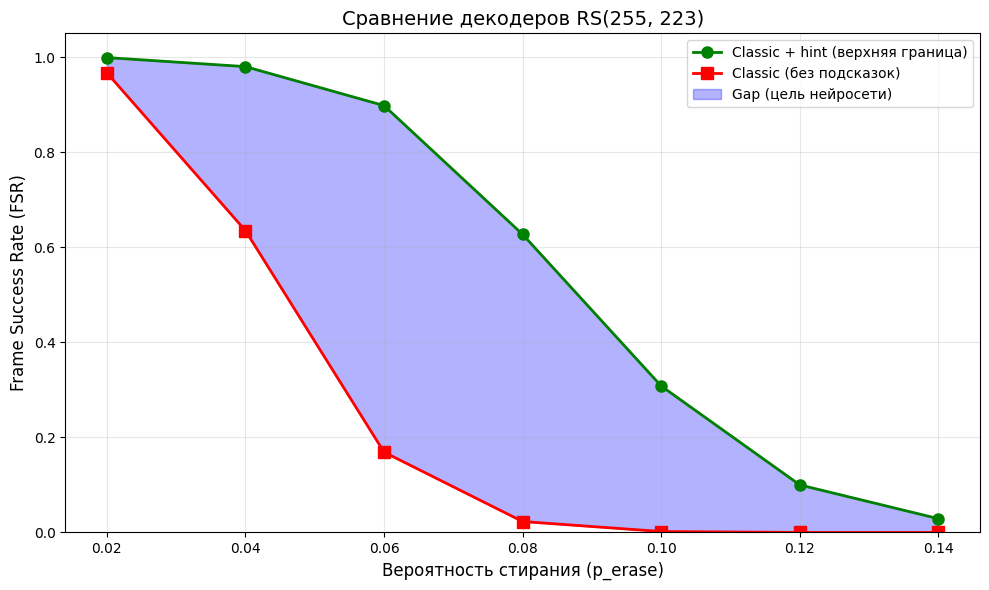

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(p_erase_values, results_hint, 'g-o', linewidth=2, markersize=8, 
         label='Classic + hint (верхняя граница)')
plt.plot(p_erase_values, results_classic, 'r-s', linewidth=2, markersize=8, 
         label='Classic (без подсказок)')

plt.fill_between(p_erase_values, results_classic, results_hint, 
                 alpha=0.3, color='blue', label='Gap (цель нейросети)')

plt.xlabel('Вероятность стирания (p_erase)', fontsize=12)
plt.ylabel('Frame Success Rate (FSR)', fontsize=12)
plt.title('Сравнение декодеров RS(255, 223)', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150)
plt.show()

## 5. Анализ проблемы

Почему Classic так плохо работает при высоких p_erase?

In [12]:
P_ERR = 0.02
P_ERASE = 0.06

msg = os.urandom(K)
codeword = rsc.encode(msg)
noisy, erase_pos = qsc_erasure_channel(codeword, P_ERR, P_ERASE)

total_errors = sum(1 for a, b in zip(codeword, noisy) if a != b)
n_erasures = len(erase_pos)

print('Анализ повреждений:')
print(f'Всего изменённых символов: {total_errors}')
print(f'Известных стираний: {n_erasures}')
print()

classic_cost = 2 * total_errors
print('Classic (без подсказок):')
print(f'Все повреждения = ошибки')
print(f'Стоимость: 2 × {total_errors} = {classic_cost}')
print(f'Лимит: 2t = 32')
print(f'Результат: {"УСПЕХ" if classic_cost <= 32 else "ПРОВАЛ"}')
print()

unknown_errors = total_errors - n_erasures
hint_cost = 2 * unknown_errors + n_erasures
print('Classic + hint:')
print(f'Стирания (известны): {n_erasures}, стоимость: {n_erasures}')
print(f'Остальные ошибки: {unknown_errors}, стоимость: 2 × {unknown_errors} = {2 * unknown_errors}')
print(f'Общая стоимость: {hint_cost}')
print(f'Лимит: 2t = 32')
print(f'Результат: {"УСПЕХ" if hint_cost <= 32 else "ПРОВАЛ"}')

Анализ повреждений:
Всего изменённых символов: 14
Известных стираний: 13

Classic (без подсказок):
Все повреждения = ошибки
Стоимость: 2 × 14 = 28
Лимит: 2t = 32
Результат: УСПЕХ

Classic + hint:
Стирания (известны): 13, стоимость: 13
Остальные ошибки: 1, стоимость: 2 × 1 = 2
Общая стоимость: 15
Лимит: 2t = 32
Результат: УСПЕХ


## 6. Выводы

1. **Проблема:** Classic декодер не знает позиции стираний → трактует их как ошибки → быстро исчерпывает лимит.

2. **Возможность:** Если передать декодеру позиции стираний (Classic + hint), эффективность резко возрастает.

3. **Идея:** Обучить нейросеть предсказывать позиции стираний по косвенным признакам (синдром, маска нулей).

4. **Цель:** Заполнить разрыв между Classic и Classic + hint.